# Exploring the Dataset

We will begin by understanding the dataset, which can be obtained via the [Bristol-Myers Squibb – Molecular Translation](https://www.kaggle.com/competitions/bms-molecular-translation/overview) page on Kaggle.  

The data consist of labelled images of molecules (2,424,187) and their associated [International Chemical Identifier (InChI) labels](https://en.wikipedia.org/wiki/International_Chemical_Identifier) in a csv file.

We will read, parse and visualise the data using the `pandas` library.


In [1]:
import pandas as pd

In [3]:
# Can use 'nrows=100' for ease during iteration
# df_train_labels = pd.read_csv("../data/train_labels.csv", nrows=100)

df_train_labels = pd.read_csv("../data/train_labels.csv")
df_train_labels.head()

,image_id,InChI
0,000011a64c74,InChI=1S/C13H20OS/c1-9(2)8-15-13-6-5-10(3)7-12...
1,000019cc0cd2,InChI=1S/C21H30O4/c1-12(22)25-14-6-8-20(2)13(1...
2,0000252b6d2b,InChI=1S/C24H23N5O4/c1-14-13-15(7-8-17(14)28-1...
3,000026b49b7e,InChI=1S/C17H24N2O4S/c1-12(20)18-13(14-7-6-10-...
4,000026fc6c36,InChI=1S/C10H19N3O2S/c1-15-10(14)12-8-4-6-13(7...


We can further split the InChI label into its component parts:

In [3]:
#creating new cols
df_train_labels[["version_standard","chemical_formula","remainder"]] = df_train_labels["InChI"].str.split("/", n=2, expand=True)

In [4]:
df_train_labels.head(10)

,image_id,InChI,version_standard,chemical_formula,remainder
0,000011a64c74,InChI=1S/C13H20OS/c1-9(2)8-15-13-6-5-10(3)7-12...,InChI=1S,C13H20OS,"c1-9(2)8-15-13-6-5-10(3)7-12(13)11(4)14/h5-7,9..."
1,000019cc0cd2,InChI=1S/C21H30O4/c1-12(22)25-14-6-8-20(2)13(1...,InChI=1S,C21H30O4,c1-12(22)25-14-6-8-20(2)13(10-14)11-17(23)19-1...
2,0000252b6d2b,InChI=1S/C24H23N5O4/c1-14-13-15(7-8-17(14)28-1...,InChI=1S,C24H23N5O4,c1-14-13-15(7-8-17(14)28-12-10-20(28)30)27-11-...
3,000026b49b7e,InChI=1S/C17H24N2O4S/c1-12(20)18-13(14-7-6-10-...,InChI=1S,C17H24N2O4S,c1-12(20)18-13(14-7-6-10-24-14)11-15(21)19-17(...
4,000026fc6c36,InChI=1S/C10H19N3O2S/c1-15-10(14)12-8-4-6-13(7...,InChI=1S,C10H19N3O2S,"c1-15-10(14)12-8-4-6-13(7-8)5-2-3-9(11)16/h8H,..."
5,000028818203,InChI=1S/C19H22Br2N2O2/c1-13(2)10-16(19(24)25)...,InChI=1S,C19H22Br2N2O2,c1-13(2)10-16(19(24)25)23(9-8-14-6-4-3-5-7-14)...
6,000029a61c01,InChI=1S/C17H10BrN3O/c18-14-7-3-1-5-11(14)9-12...,InChI=1S,C17H10BrN3O,c18-14-7-3-1-5-11(14)9-12(10-19)16-20-15-8-4-2...
7,000035624718,InChI=1S/C21H21N5O2S/c1-15-7-8-18(17-5-4-11-22...,InChI=1S,C21H21N5O2S,"c1-15-7-8-18(17-5-4-11-22-20(15)17)29(27,28)25..."
8,00003e900ef4,InChI=1S/C13H18N2O5S/c1-4-10(13(17)18)15-12(16...,InChI=1S,C13H18N2O5S,c1-4-10(13(17)18)15-12(16)9-5-7(2)8(3)11(6-9)2...
9,000045d5fbf9,InChI=1S/C13H15BrN2O3/c1-7-5-15-6-9(7)12(17)16...,InChI=1S,C13H15BrN2O3,c1-7-5-15-6-9(7)12(17)16-11-3-2-8(13(18)19)4-1...


Are they all version 1 and standard? (spoiler - yes)

In [5]:
df_train_labels['version_standard'].describe()

count      2424186
unique           1
top       InChI=1S
freq       2424186
Name: version_standard, dtype: object

### Understanding the elements

Now we have a breakdown of all the molecules, including a breakdown of their elemental composition, we can do some analysis.  For example, how many different elements are present and in what quantities?

We can write a simple regex to count the elements given a formula of the form `AiBjCdk`, where `A, B, Cd` are elements, and `i,j,k` their counts.  The regex looks like `([A-Z][a-z]?)(\d*)` and can be broken down as follows:

- `[A-Z]` matches a capital letter, so `A` `B` and `C` in our example.
- `[a-z]?` optionally matches a lower case (0 or 1 occurance), will match the `d` in our case.  Elements are only ever an uppercase letter followed by zero or one lowercase letters.
- `(\d)` captures any digit after the number, and the `*` catches 0 or more.  If it finds zero, we can replace it with a one since single element counts in a molecule do not get given an explicit `1` count.

In [6]:
import re

def parse_formula(formula):
    parts = re.findall(r'([A-Z][a-z]?)(\d*)', formula)
    return {
        element: int(count) if count else 1
        for element, count in parts
    }

print(parse_formula("C13H15BrN2O3"))


parts = re.findall(r'([A-Z][a-z]?)(\d*)', "C13H15BrN2O3")
print(parts)

{'C': 13, 'H': 15, 'Br': 1, 'N': 2, 'O': 3}
[('C', '13'), ('H', '15'), ('Br', ''), ('N', '2'), ('O', '3')]


We could capture it in a formula like this, but we will use the vectorised way of doing it. `re.findall` is vectorised, so applying it to the whole column, rather than row by row will be much faster


In [7]:
df_parts = pd.DataFrame()
df_parts["parts"] =  df_train_labels["chemical_formula"].str.findall(r'([A-Z][a-z]?)(\d*)')

In [8]:
df_parts["parts"]

0                           [(C, 13), (H, 20), (O, ), (S, )]
1                                 [(C, 21), (H, 30), (O, 4)]
2                         [(C, 24), (H, 23), (N, 5), (O, 4)]
3                  [(C, 17), (H, 24), (N, 2), (O, 4), (S, )]
4                  [(C, 10), (H, 19), (N, 3), (O, 2), (S, )]
                                 ...                        
2424181           [(C, 10), (H, 12), (F, 2), (N, 2), (O, 3)]
2424182    [(C, 19), (H, 20), (F, 2), (N, 4), (O, 3), (S, )]
2424183    [(C, 22), (H, 26), (Cl, 2), (N, 2), (O, 4), (S...
2424184            [(C, 17), (H, 26), (N, 2), (O, 6), (S, )]
2424185           [(C, 10), (H, 18), (N, 2), (O, 9), (P, 2)]
Name: parts, Length: 2424186, dtype: object

`explode` will decompose the dataframe into one long series. It reshapes data without python loops so will be fast.

In [9]:
df_exploded = df_parts.explode("parts")
df_exploded

,parts
0,"(C, 13)"
0,"(H, 20)"
0,"(O, )"
0,"(S, )"
1,"(C, 21)"
...,...
2424185,"(C, 10)"
2424185,"(H, 18)"
2424185,"(N, 2)"
2424185,"(O, 9)"


We can separate the elements out and work out a count for each

In [10]:
df_exploded[["element", "count"]] = pd.DataFrame(
    df_exploded["parts"].tolist(), index=df_exploded.index
)
df_exploded["count"] = df_exploded["count"].replace("", "1").astype(int)
df_exploded

,parts,element,count
0,"(C, 13)",C,13
0,"(H, 20)",H,20
0,"(O, )",O,1
0,"(S, )",S,1
1,"(C, 21)",C,21
...,...,...,...
2424185,"(C, 10)",C,10
2424185,"(H, 18)",H,18
2424185,"(N, 2)",N,2
2424185,"(O, 9)",O,9


Finally we can create a pivot table to summarise what we have on a molecule by molecule (row by row) basis.

In [11]:
element_counts = df_exploded.pivot_table(
    index=df_exploded.index,
    columns="element",
    values="count",
    aggfunc="sum",
    fill_value=0
)
element_counts

element,B,Br,C,Cl,F,H,I,N,O,P,S,Si
0,0,0,13,0,0,20,0,0,1,0,1,0
1,0,0,21,0,0,30,0,0,4,0,0,0
2,0,0,24,0,0,23,0,5,4,0,0,0
3,0,0,17,0,0,24,0,2,4,0,1,0
4,0,0,10,0,0,19,0,3,2,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2424181,0,0,10,0,2,12,0,2,3,0,0,0
2424182,0,0,19,0,2,20,0,4,3,0,1,0
2424183,0,0,22,2,0,26,0,2,4,0,1,0
2424184,0,0,17,0,0,26,0,2,6,0,1,0


In [12]:
f"Total atom count: {element_counts.sum().sum():,}"

'Total atom count: 110,945,832'

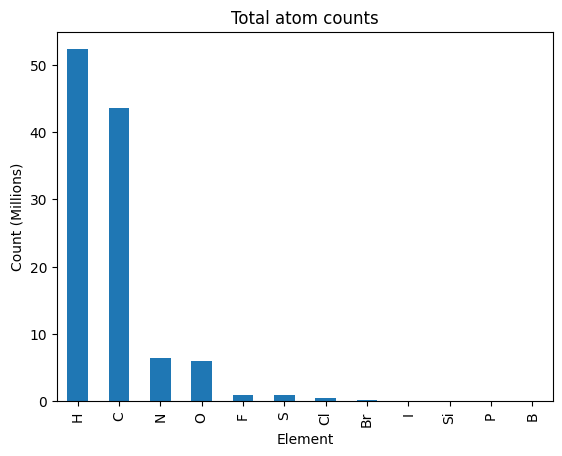

In [13]:
import matplotlib.pyplot as plt

element_counts.sum().div(1e6).sort_values(ascending=False).plot(kind="bar")
plt.title("Total atom counts")
plt.xlabel("Element")
plt.ylabel("Count (Millions)")
plt.show()

As expected, H, C, N and O dominate the counts. This is organic chemistry!

We avoided using `apply` to use our regex to expand into columns - it is slowwww as it uses python loops

`df_speed_test = df_train_labels["chemical_formula"].apply(parse_formula).apply(pd.Series)`

We have over 2.4 million molecules (rows) and 110 Million atoms so this would take a long time to complete.

Now that we have a little bit better of an understanding of the dataset, if we are to attempt to work with molecular images we should understand a little better how we can draw them.  This will be attempted in [the 02_drawinging_molecules.ipynb notebook](./02_drawing_molecules.ipynb).